In [4]:
from tools import Aromatics, HBonds, t_stack, pi_stack, rm_index, canonical_residues, block_error
from writhe_tools.utils import group_by, lsdir
from writhe_tools.md_tools  import ResidueDistances, get_residues, traj_slice, calc_sa
from writhe_tools.plots import lineplot1D, fes2d, proj2d
from writhe_tools.writhe import Writhe
from writhe_tools.stats import pca, Kmeans
from writhe_tools.tcca import CCA


import mdtraj as md
from functools import partial
import numpy as np
import matplotlib.pyplot as plt
from writhe_tools.md_tools import plot_distance_matrix



isin_index = lambda x, y : np.where(np.isin(x, y))[0]

def fill(x, index, val):
    x[:, index] = val
    return x


def sigmoid(x, shift=1, scale=1):
    return 1 - 1 / (1 + np.exp(-scale * (x - shift)))

In [5]:
pdb = 'prot.pdb'
traj_file = 'r/rep.0.xtc'


trj = md.load(traj_file, top=pdb)
sequence, ca_index = get_residues(trj)
ca_sequence = sequence[ca_index]
codes = np.array(list(trj.top.to_fasta()[0]))[ca_index]


In [6]:
trj

<mdtraj.Trajectory with 45917 frames, 817 atoms, 72 residues, and unitcells at 0x7fd00c0a0220>

#  protein Interactions

/home/kaushikb/miniconda3/envs/writhe/lib/python3.10/site-packages/writhe_tools/writhe.py:96: UserWarning: operator() profile_node %141 : int[] = prim::profile_ivalue(%new_shape.2)
 does not have profile information (Triggered internally at ../third_party/nvfuser/csrc/graph_fuser.cpp:104.)
  result = torch.cat([writhe_segments(xyz,


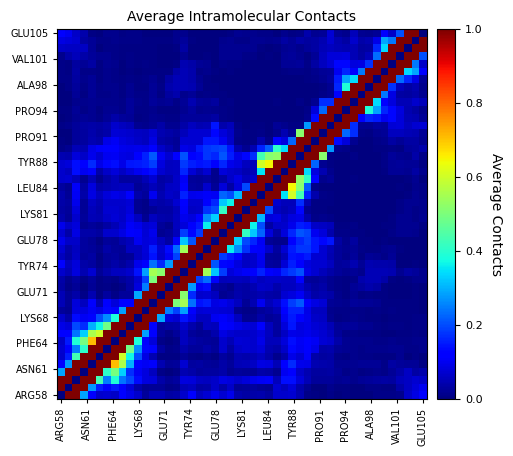

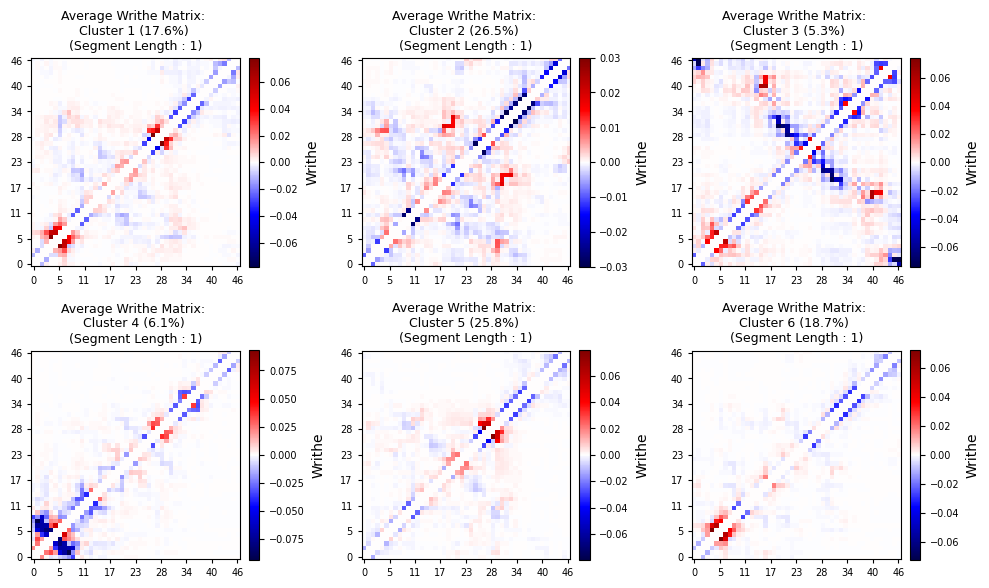

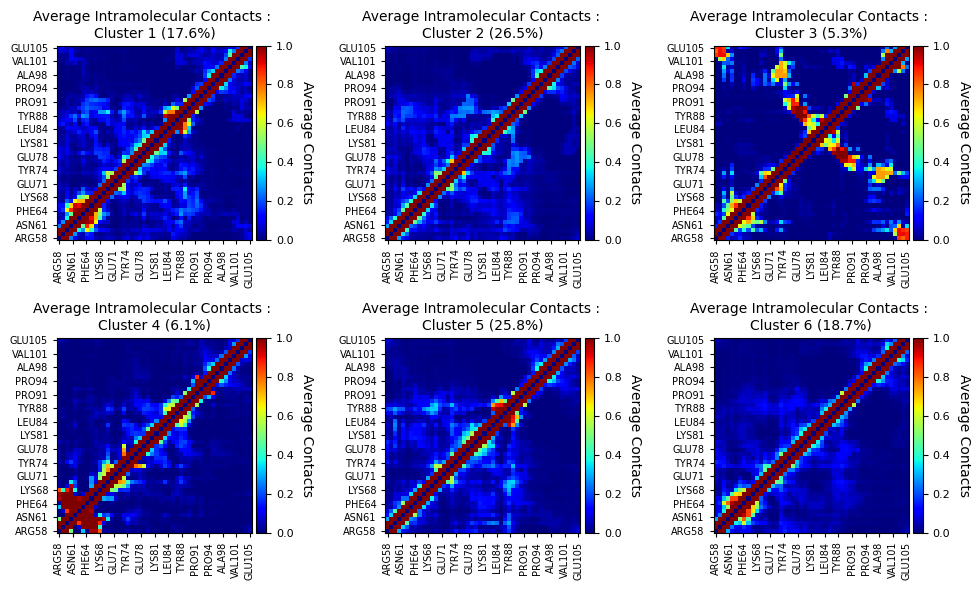

In [7]:
protein_distances = ResidueDistances(traj = trj, index_0=ca_index)
protein_distances.plot(xticks_rotation=90, contacts=True, contact_cutoff=0.6, )
protein_distances.save(dscr='protein_distances_300k')

writhe = Writhe(traj_slice(trj, 'name CA').center_coordinates().xyz)
writhe.compute_writhe(1, cuda = True)

sa = calc_sa(trj, 'W76A_helix.pdb')
rg = md.compute_rg(trj)

pca_proj, sigmas = pca(writhe.writhe_features)[:-1]

dtraj, frames, centers = Kmeans(pca_proj, n_clusters=6, n_dim=3, return_all=True)[:3]

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
for i,( ax, indices) in enumerate(zip(axes.flat, frames)):
    writhe.plot_writhe_matrix(indices, ax=ax, dscr=f'\nCluster {i+1} ({100 * len(indices) / len(dtraj):.1f}%)', xticks_rotation=0)
fig.tight_layout()

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
for i,( ax, indices) in enumerate(zip(axes.flat, frames)):
    protein_distances.plot(indices, ax=ax, dscr=f'\nCluster {i+1} ({100 * len(indices) / len(dtraj):.1f}%)', xticks_rotation=90,  contact_cutoff=0.6, contacts=True)
fig.tight_layout()



# Ligand Interactions 

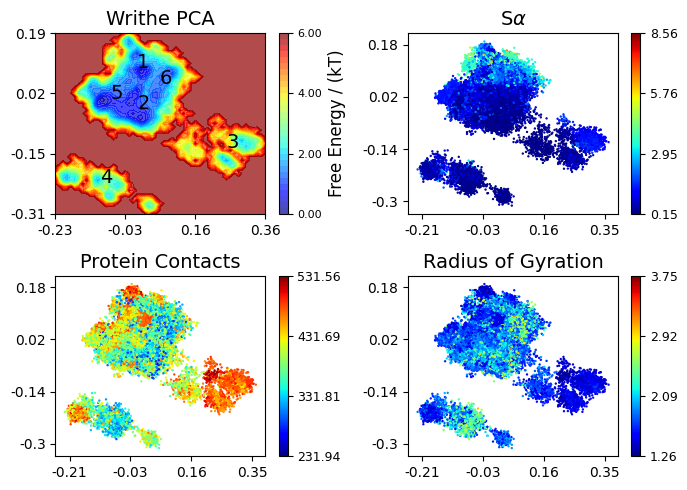

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(7, 5))
fes2d(pca_proj[:,:2], bins=55, contour_lines=False, alpha_contours=.7, n_contours=30, alpha_lines=.2, cluster_centers=centers[:,:2], mask=False,
      ax=axes[0,0], title='Writhe PCA', cluster_label_size=14)

proj2d(pca_proj[:, :2], c=sa.sum(-1), ax=axes[0,1], title=r'S$\alpha$')
proj2d(pca_proj[:, :2], c=sigmoid(protein_distances.distances).sum(-1), title=r'Protein Contacts', ax=axes[1,0])
proj2d(pca_proj[:, :2], c=rg, title=r'Radius of Gyration',  ax=axes[1,1])

fig.tight_layout()

In [9]:
rg = md.compute_rg(trj)

In [10]:
sa_total = sa.sum(-1)

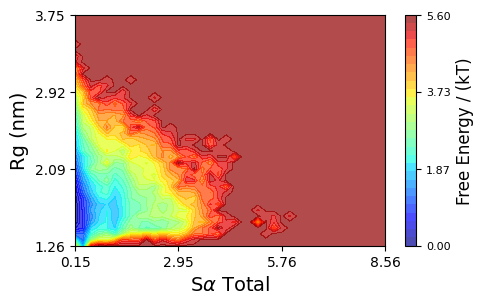

In [11]:
fes2d(
    sa_total,
    rg,
    xlabel=r'S$\alpha$'+" Total",
      ylabel="Rg (nm)",
     bins=40,
      mask=False,
      contour_lines=False,
      alpha_contours=.7, alpha_lines=.1, mask_thresh=5,
      n_contours=30)

In [12]:
dssp_H = np.where(md.compute_dssp(traj=md.load(traj_file, top=pdb)) == 'H', 1, 0)[:, ca_index]
dssp_E = np.where(md.compute_dssp(traj=md.load(traj_file, top=pdb)) == 'E', 1, 0)[:, ca_index]

In [13]:
H_err = block_error(dssp_H)[1]
E_err = block_error(dssp_E)[1]

/home/kaushikb/miniconda3/envs/writhe/lib/python3.10/site-packages/pyblock/blocking.py:256: RuntimeWarning: invalid value encountered in scalar divide
  if B3 > 2*ndata*(var_std_err/std_err_first[i])**4:


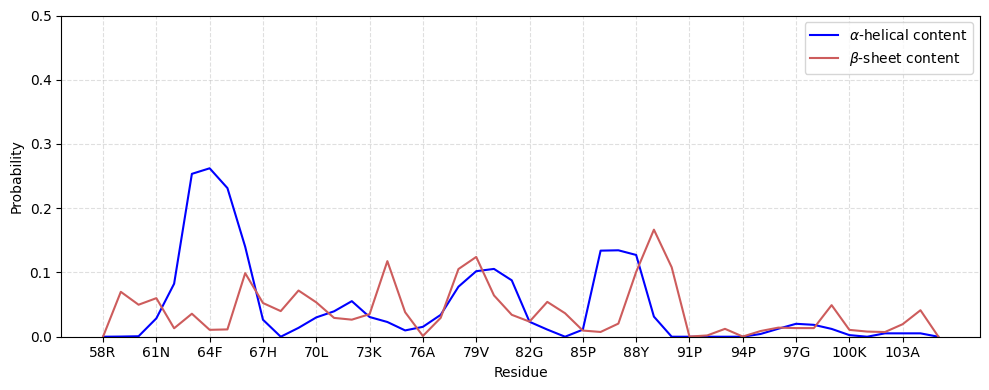

In [14]:
labels = [f"{i+58}{aa}" for i, aa in enumerate(codes)]
x = np.arange(len(codes))

plt.figure(figsize=(10, 4))
plt.plot(x, dssp_H.mean(0), label=r'$\alpha$-helical content', color='blue')
plt.plot(x, dssp_E.mean(0), label=r'$\beta$-sheet content', color='indianred')

plt.xticks(x[::3], labels[::3], rotation=0) 
plt.xlabel("Residue")
plt.ylabel("Probability")
plt.legend()
plt.ylim(0, 0.5)
plt.tight_layout()
plt.grid(True, which='major', linestyle='--', alpha=0.4)
plt.show()


In [15]:
from writhe_tools.plots import build_matrix_boxplot_grid
from writhe_tools.utils import makedirs
import visualize
from visualize import palettes
def visualize_clustering(traj, frames, path, name, num_frames=20, ref=None, features=None, ax=None):
    
    frames = frames[:num_frames] if len(frames) >= num_frames else frames
    betas = features[frames].mean(0) if features is not None else None
    makedirs(f"{path}/images")
    
    visualize.plot_structure(visualize.make_structures(traj,
                                                       indices=frames,
                                                       dir=f"{path}/images",
                                                       ensemble=True,
                                                       overwrite=True,
                                                       transparency=.1,
                                                       draw_style="cartoon",
                                                       name=name,
                                                       palette = palettes['coolwarm'],
                                                       save_state=True,
                                                       cartoon_loop_radius=.15,
                                                       ref=ref,
                                                       beta_values=betas),
                         legend=False,
                         title=name,
                         ax=ax,
                         cbar=True if betas is not None else False,
                         cmap="coolwarm",
                         vmin=betas.min() if betas is not None else None,
                         vmax=betas.max() if betas is not None else None,
                         cbar_label="RMSF (nm)" if betas is not None else None,
    )

In [16]:
from writhe_tools.md_tools import traj_slice, get_residues, rmsd_sort
indices = np.fromiter([i for i, j in enumerate(get_residues(trj)[0]) if not (j.startswith('NA') or j.startswith('CL'))], int)

frames_rmsd = [rmsd_sort(i, traj_slice(trj, f'resid {indices[0]} to {indices[-1]}'))
                for i in frames]

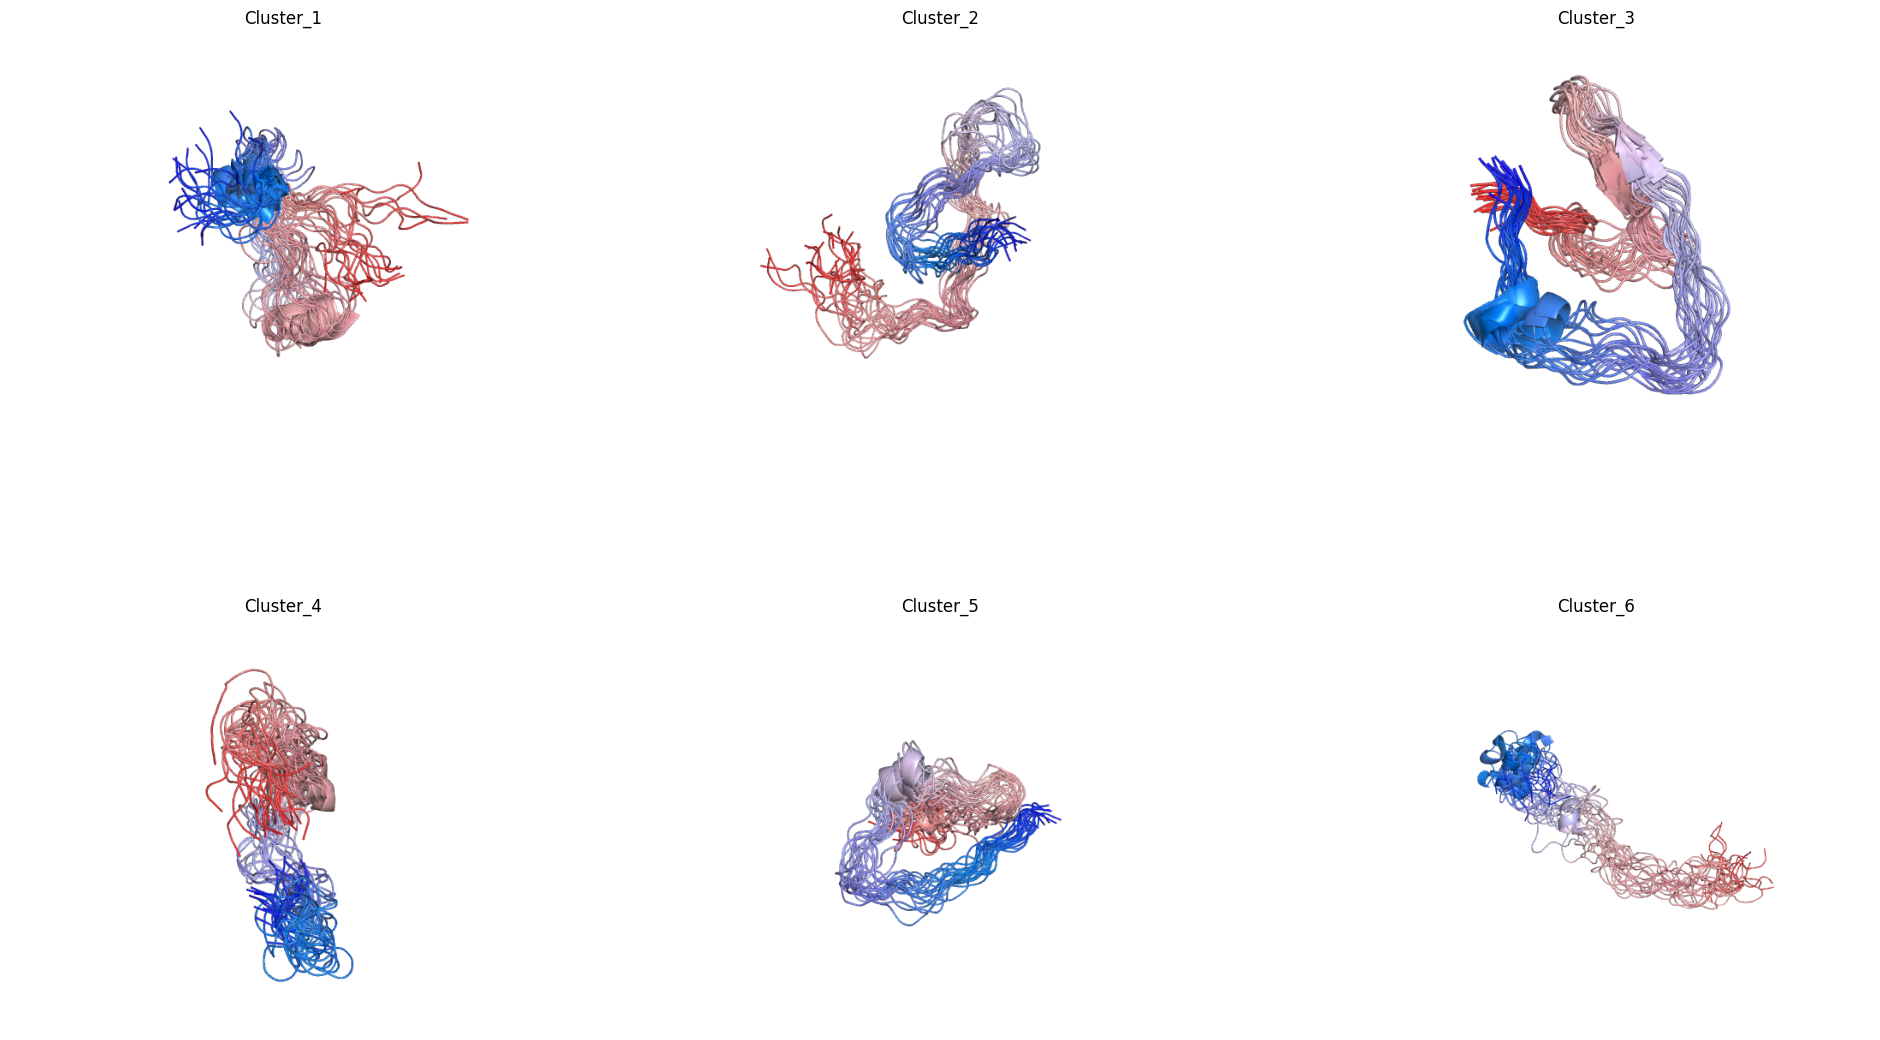

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
for i, (frame, ax) in enumerate(zip(frames_rmsd, axes.flat)):
    visualize_clustering(traj_slice(trj, f'resid {indices[0]} to {indices[-1]}'), frame, './', f'Cluster_{i+1}', ax=ax)